In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from config import AGGREGATIONS, BENCHMARKS, RANDOM_SEED
from utils import load_dataset, plot_pool_distribution, print_summary, SOURCE_MAP
from scoring.runner import score_source, scores_path
from selection import select_source, save_selection

AGGREGATION = "10min"
BENCHMARK = "WORKERS"
AGG_PARAMS = AGGREGATIONS[AGGREGATION]
BENCH_PARAMS = BENCHMARKS[BENCHMARK]

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

print(f"Benchmark: {BENCHMARK}")
print(f"Aggregation: {AGGREGATION}")
print(f"Threshold: {BENCH_PARAMS['metric_col']} {BENCH_PARAMS['metric_op']} {BENCH_PARAMS['threshold']}")
print(f"Sparsity min: {BENCH_PARAMS['sparsity_min']}")
print(f"Sample size: {BENCH_PARAMS['sample_size']} | Seed: {RANDOM_SEED}")

Benchmark: WORKERS
Aggregation: 10min
Threshold: whr >= 0.6
Sparsity min: 0.23
Sample size: 25 | Seed: 42


## 1 — Scoring

In [2]:
sources = BENCH_PARAMS["levels"]
scores = {}

for source in sources:
    path = scores_path(AGGREGATION, BENCHMARK, source)
    if os.path.exists(path):
        print(f"Loading existing scores: {path}")
        scores[source] = pd.read_csv(path)
    else:
        print(f"Computing scores for {source}...")
        scores[source] = score_source(BENCHMARK, source, aggregation=AGGREGATION)

for source, df in scores.items():
    print(f"\n{source}: {len(df)} series scored")
    display(df.describe().round(3))

Loading existing scores: scores/10min/WORKERS_ips.csv

ips: 1000 series scored


,id_ip,ratio_active,whr,total_active_intervals,work_active_intervals
count,1000.000,1000.000,203.000,203.000,203.000
mean,860461.454,0.170,0.319,25429.990,8014.793
std,679140.522,0.265,0.036,10595.587,3245.777
min,11.000,0.003,0.259,9425.000,2782.000
25%,266825.500,0.019,0.302,15550.000,5131.500
50%,635072.500,0.055,0.311,25762.000,7927.000
75%,1629478.250,0.155,0.314,35448.000,11015.000
max,2044888.000,1.000,0.535,40298.000,12605.000


## 2 — Score distributions

Histogram of `whr` per level with the selection threshold overlaid.

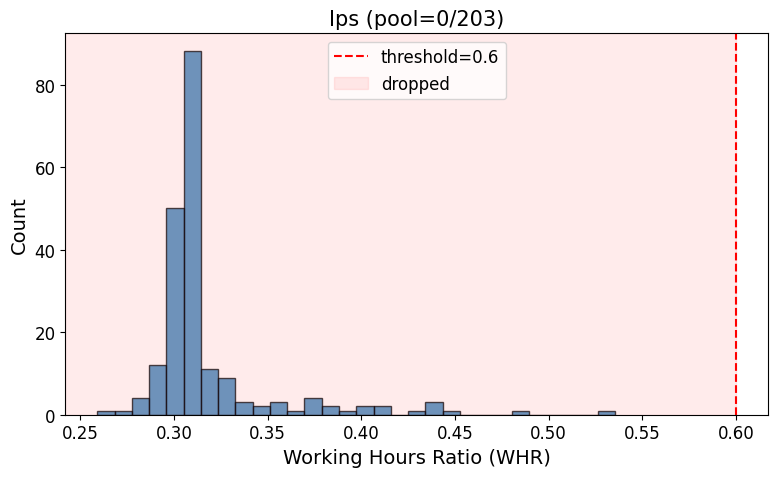

In [3]:
_smin = BENCH_PARAMS["sparsity_min"]
active_scores = {
    s: scores[s][scores[s]["ratio_active"] >= _smin]
    for s in sources
}

plot_pool_distribution(
    [(active_scores[s], s.capitalize()) for s in sources],
    metric_col=BENCH_PARAMS["metric_col"],
    threshold=BENCH_PARAMS["threshold"],
    xlabel="Working Hours Ratio (WHR)",
)

## 3 — Selection

Apply sparsity filter, threshold filter, then random sample from the qualifying pool.

In [4]:
selected = {}
pool_sizes = {}

for source in sources:
    ids, pool_size, _ = select_source(BENCHMARK, source, AGGREGATION)
    selected[source] = ids
    pool_sizes[source] = pool_size

print_summary(
    BENCHMARK,
    selected,
    pool_sizes,
    threshold=BENCH_PARAMS["threshold"],
    threshold_name=BENCH_PARAMS["metric_col"],
    sample_size=BENCH_PARAMS["sample_size"],
    seed=RANDOM_SEED,
)

  ips: 203/1000 pass sparsity, pool=0 — empty pool!

WORKERS BENCHMARK - Selected Series
Threshold: whr >= 0.6
Selection: Random sample of 25 from qualifying pool
Random seed: 42

ips (0): []
  Pool size: 0


### IP sample pool exhausted — fall back to full IP dataset

In [5]:
path = scores_path(AGGREGATION, BENCHMARK, "ips_full")
if os.path.exists(path):
    print(f"Loading existing scores: {path}")
    scores["ips_full"] = pd.read_csv(path)
else:
    print(f"Computing scores for ips_full (chunked)...")
    scores["ips_full"] = score_source(BENCHMARK, "ips_full", aggregation=AGGREGATION)

print(f"\nips_full: {len(scores['ips_full'])} series scored")
display(scores["ips_full"].describe().round(3))

ids, pool_size, _ = select_source(BENCHMARK, "ips_full", AGGREGATION)
selected["ips"] = ids
pool_sizes["ips"] = pool_size

print(f"\nips selected from full dataset ({len(ids)}): {ids}")
print(f"Pool size: {pool_size}")


Loading existing scores: scores/10min/WORKERS_ips_full.csv

ips_full: 275124 series scored


,id_ip,ratio_active,whr,total_active_hours,work_active_hours
count,275124.000,275124.000,275124.000,275124.000,275124.000
mean,883801.658,0.150,0.388,6030.654,2113.806
std,666745.924,0.236,0.126,9507.755,2950.336
min,3.000,0.000,0.002,7.000,1.000
25%,293947.500,0.019,0.299,765.000,230.000
50%,650919.500,0.051,0.321,2074.000,979.000
75%,1623585.000,0.138,0.477,5581.250,2440.000
max,2055783.000,1.000,1.000,40298.000,12605.000


  ips_full: 49513/275124 pass sparsity, pool=34 — selected 25

ips selected from full dataset (25): [3846, 21939, 29898, 53673, 111517, 187291, 272399, 303078, 323771, 330940, 333372, 351284, 367407, 438509, 460989, 508147, 514692, 517910, 568739, 672019, 673645, 811277, 818999, 1488481, 1513237]
Pool size: 34


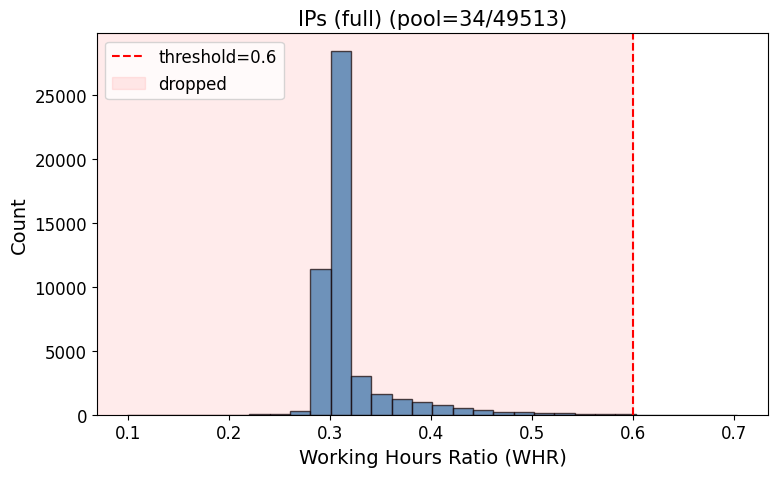

In [6]:
_full_active = scores["ips_full"][scores["ips_full"]["ratio_active"] >= _smin]
plot_pool_distribution(
    [(_full_active, "IPs (full)")],
    metric_col=BENCH_PARAMS["metric_col"],
    threshold=BENCH_PARAMS["threshold"],
    xlabel="Working Hours Ratio (WHR)",
)

## 4 — Detailed scores for selected series

In [7]:
for source in sources:
    _, id_col = SOURCE_MAP[source]
    df_s = scores.get("ips_full") if source == "ips" and "ips_full" in scores else scores[source]
    sel = df_s[df_s[id_col].isin(selected[source])].sort_values("whr", ascending=False)
    print(f"\n{source.capitalize()} — selected series scores:")
    display(sel)


Ips — selected series scores:


,id_ip,ratio_active,whr,total_active_hours,work_active_hours
8855,29898.0,0.250583,0.703704,10098.0,7106.0
122838,568739.0,0.262891,0.678969,10594.0,7193.0
1307,3846.0,0.234801,0.673114,9462.0,6369.0
76896,333372.0,0.257655,0.665029,10383.0,6905.0
171984,1488481.0,0.252519,0.660279,10176.0,6719.0
64178,272399.0,0.283017,0.649364,11405.0,7406.0
83818,367407.0,0.246241,0.644261,9923.0,6393.0
112855,514692.0,0.246017,0.643837,9914.0,6383.0
74961,323771.0,0.241699,0.632033,9740.0,6156.0
76424,330940.0,0.250112,0.628038,10079.0,6330.0


## 5 — Verification plots

For a few selected series: raw time series with weekend/holiday shading and weekly activity heatmap.

In [8]:
def plot_workstation_verification(df, id_col, ts_id, non_work_days):
    grp = df[df[id_col] == ts_id].copy().reset_index(drop=True)
    y = grp["n_bytes"].values.astype(float)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    grp["day"] = grp["datetime"].dt.normalize()
    grp["is_non_work"] = grp["day"].isin(non_work_days)

    axes[0].plot(grp["datetime"].values, y, linewidth=0.3, alpha=0.7)

    p99 = np.percentile(y[y > 0], 99) if (y > 0).any() else y.max()
    axes[0].set_ylim(-p99 * 0.03, p99 * 1.1)

    mask = grp["is_non_work"].values.astype(int)
    changes = np.diff(mask)
    starts = np.where(changes == 1)[0] + 1
    ends = np.where(changes == -1)[0] + 1
    if mask[0] == 1:
        starts = np.r_[0, starts]
    if mask[-1] == 1:
        ends = np.r_[ends, len(mask)]
    for s, e in zip(starts, ends):
        axes[0].axvspan(grp["datetime"].iloc[s], grp["datetime"].iloc[e - 1],
                        alpha=0.1, color="slategray")

    axes[0].set_title(f"IPs | ID = {int(ts_id)}  —  Raw n_bytes (shaded = weekends/holidays)")
    axes[0].set_ylabel("n_bytes")
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[0].grid(True, alpha=0.3)

    grp["hour_of_week"] = grp["datetime"].dt.dayofweek * 24 + grp["datetime"].dt.hour
    active_profile = grp.groupby("hour_of_week")["n_bytes"].apply(lambda x: (x > 0).mean())

    heatmap = np.zeros((7, 24))
    for how, val in active_profile.items():
        heatmap[how // 24, how % 24] = val

    im = axes[1].imshow(heatmap, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
    axes[1].set_yticks(range(7))
    axes[1].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    axes[1].set_xticks(range(0, 24, 2))
    axes[1].set_xlabel("Hour of day")
    axes[1].set_title("Activity probability by hour-of-week")
    plt.colorbar(im, ax=axes[1], label="P(active)")

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

100%|████████████████████████████| 3/3 [00:07<00:00,  2.57s/it]



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.IP_ADDRESSES_FULL

    Time series
        Time series IDS: [514692  29898 568739], Length=3
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test ba

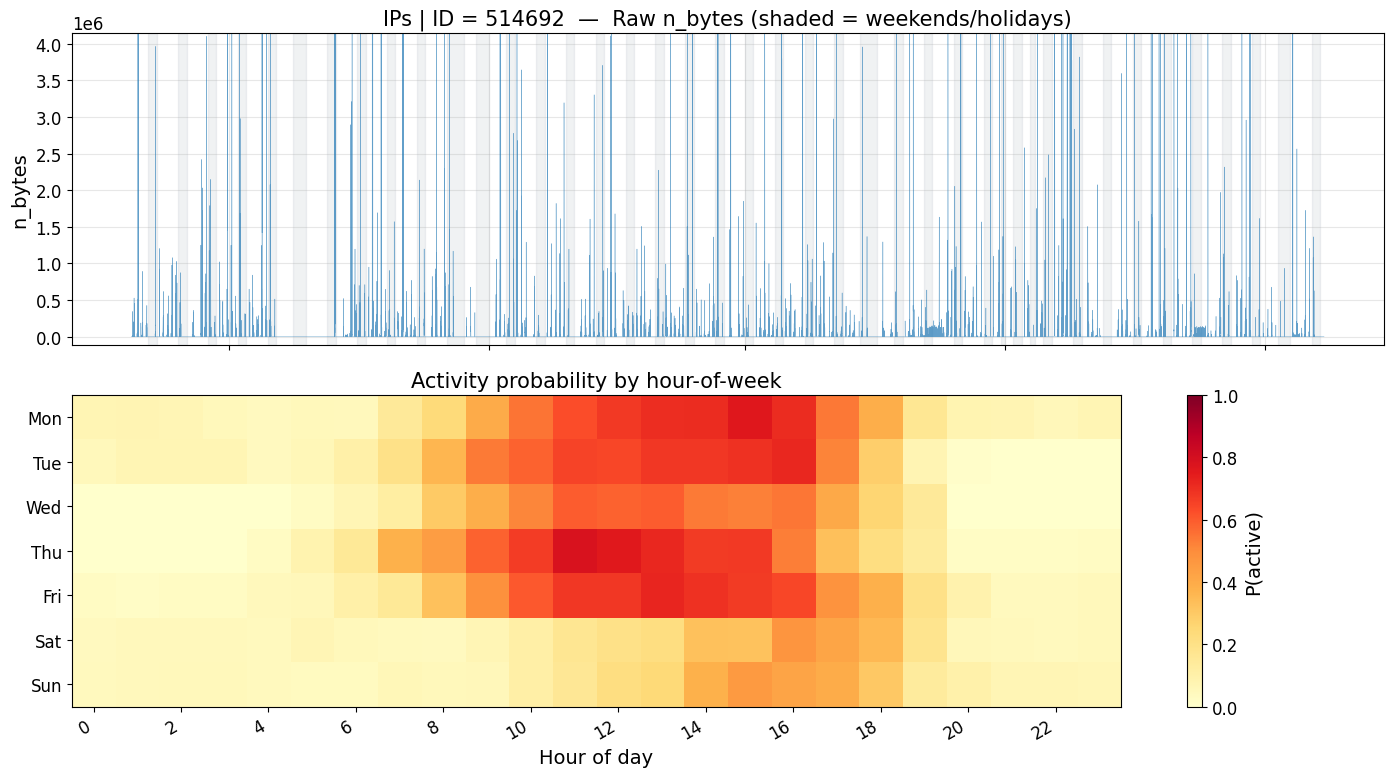

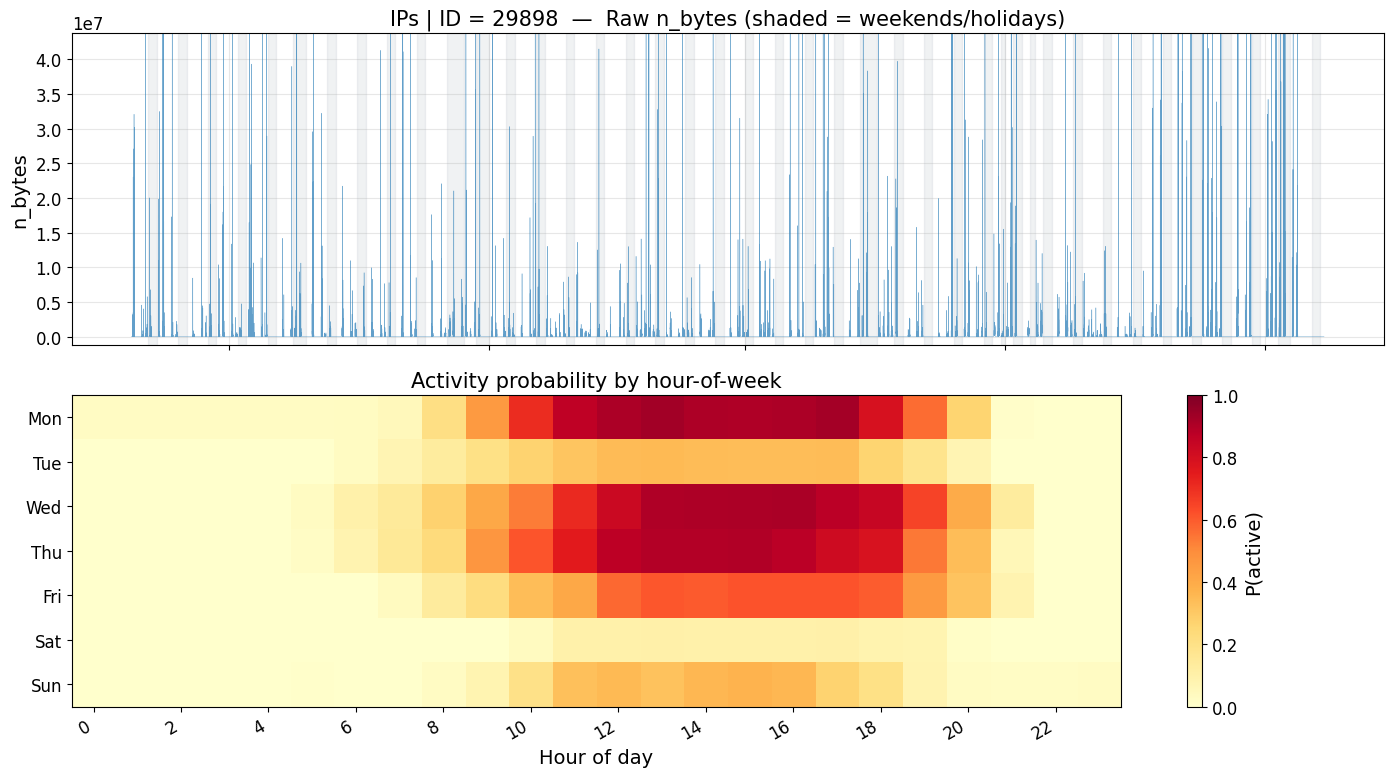

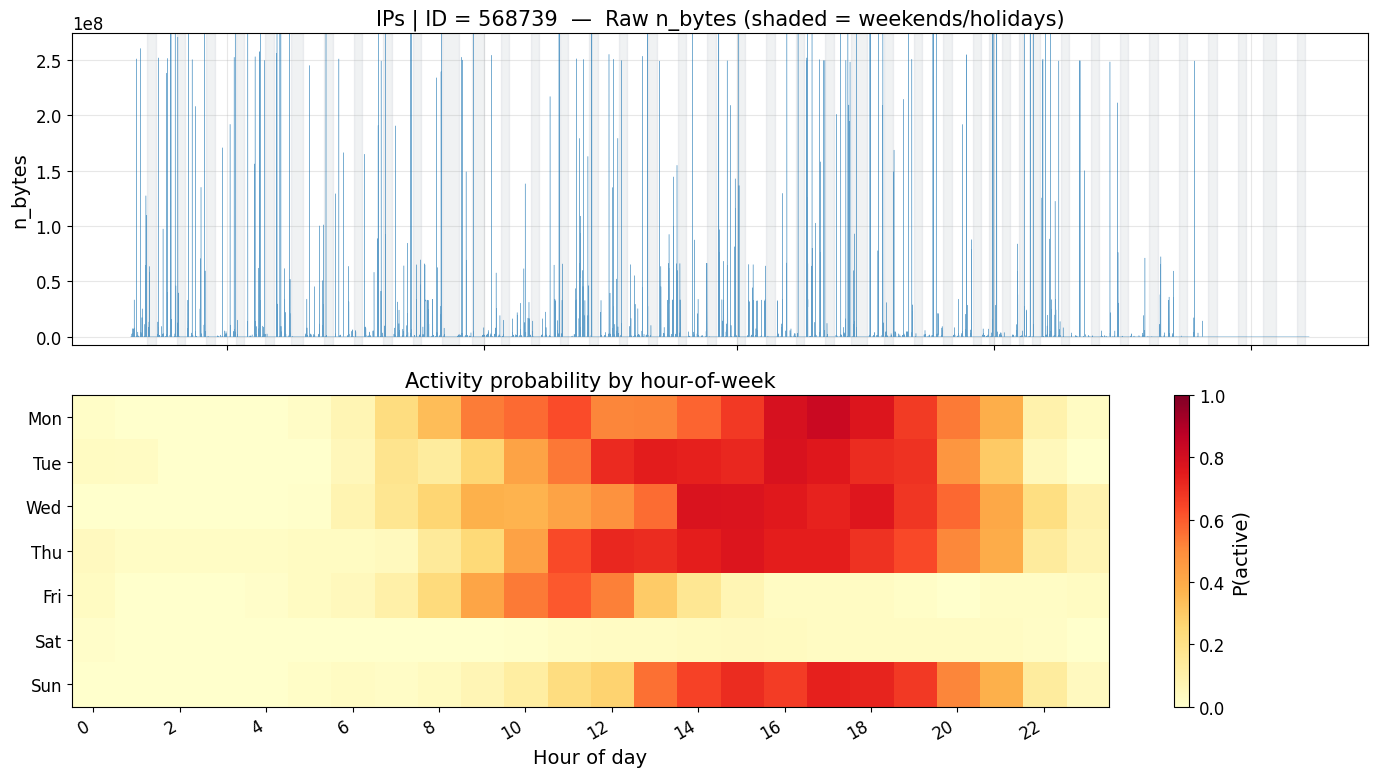

In [9]:
N_VERIFY = 3
rng = np.random.default_rng(RANDOM_SEED)

for source in sources:
    _, id_col = SOURCE_MAP[source]
    verify_ids = rng.choice(selected[source], size=min(N_VERIFY, len(selected[source])), replace=False).tolist()
    load_source = "ips_full" if source == "ips" and "ips_full" in scores else source
    data = load_dataset(load_source, aggregation=AGG_PARAMS["enum"], time_range=AGG_PARAMS["time_range"], ts_ids=verify_ids)
    df = data["df"]

    wh = data["dataset"].get_additional_data("weekends_and_holidays").copy()
    wh["day"] = pd.to_datetime(wh["Date"]).dt.normalize()
    non_work_days = set(wh["day"])
    print(f"Non-working days in calendar: {len(non_work_days)}")

    print(f"\n{'='*60}")
    print(f"{source.upper()} — verifying {len(verify_ids)} series")
    print(f"{'='*60}")
    for ts_id in verify_ids:
        plot_workstation_verification(df, id_col, ts_id, non_work_days)

## 6 — Save selection

In [10]:
save_selection(selected, BENCHMARK, AGGREGATION)

Saved selected_ids/10min/WORKERS.csv (25 series)


'selected_ids/10min/WORKERS.csv'